Comment from sklearn: Next, we illustrate the problem of high variance more clearly by using a tiny synthetic dataset. We sample only two data points, then repeatedly add small Gaussian noise to them and refit both OLS and Ridge. We plot each new line to see how much OLS can jump around, whereas Ridge remains more stable thanks to its penalty term.

In [37]:
import pandas as pd
import seaborn as sns
import sklearn
import numpy as np
import matplotlib.pyplot as plt

[Documentation of np.c_](https://numpy.org/doc/stable/reference/generated/numpy.c_.html#numpy.c_)

[scatter zorder demo](https://matplotlib.org/3.1.1/gallery/misc/zorder_demo.html)

# prepare data

In [ ]:
X_train = np.c_[0.5, 1].T
y_train = [0.5, 1]
X_test = np.c_[0,2].T #endpoints wegere each fitted model is evaluated, not actual test observations!

np.random.seed(0)

# initialize linear models

In [39]:
from sklearn.linear_model import LinearRegression, Ridge

ridge_alpha_value = 0.1
classifiers = dict(ols = LinearRegression(),
                   ridge = Ridge(alpha = ridge_alpha_value))

[Ridge](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.Ridge.html#sklearn.linear_model.Ridge) is actually OLS with L2 regularization. 
Alpha controls the regularization strengh, by multiplying the L2 norm.


# apply models and plot results

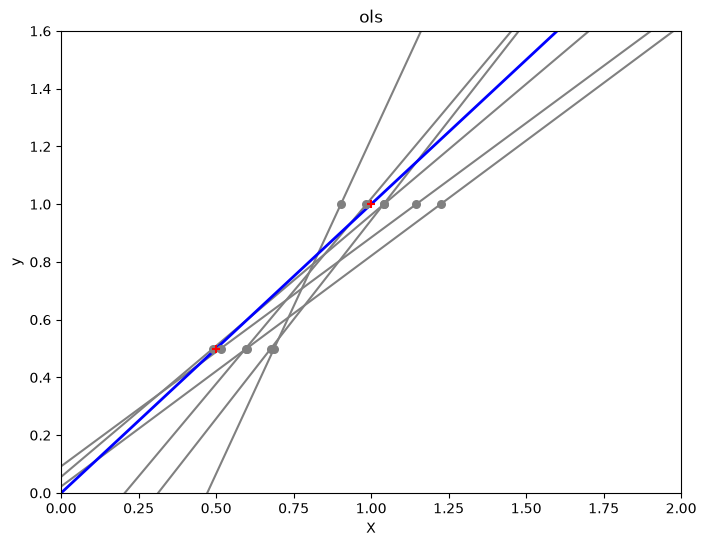

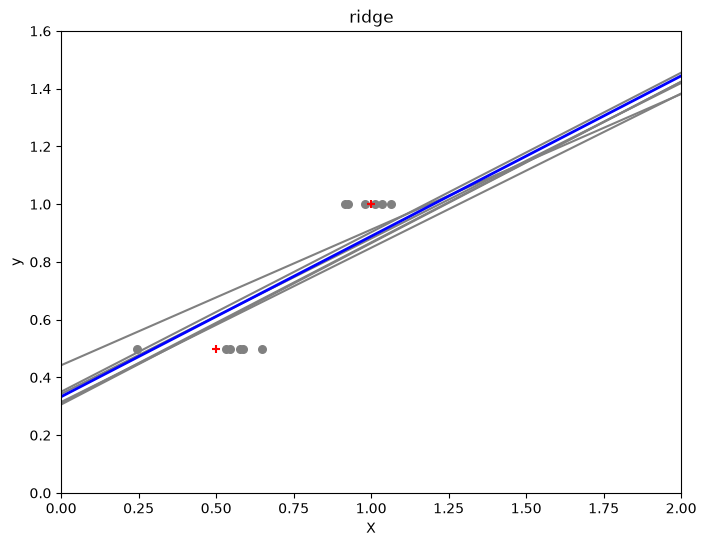

In [40]:
for name, clf in classifiers.items():
    fig, ax = plt.subplots(figsize = (8, 6))

    for _ in range(6): #add gaussian noise and refit
        this_X = 0.1 * np.random.normal(size = (2,1)) + X_train
        clf.fit(this_X, y_train) # estimate beta hat vector on newly noised data

        this_y_test_pred = clf.predict(X_test) #this_, because new clf for each iteration 
        ax.plot(X_test, this_y_test_pred, # plot regression line on this_ test data
                color = 'gray') 
        ax.scatter(this_X, y_train, # plot this_ training data
                   s = 30,
                   c = 'gray',
                   marker = 'o',
                   zorder = 10) 

    clf.fit(X_train, y_train) # estimate beta hat vector on original data 
    y_test_pred = clf.predict(X_test)
    ax.plot(X_test, y_test_pred, # plot regression line on original test data
            linewidth = 2,
            color = 'blue') 
    ax.scatter(X_train, y_train, # plot original training data
               s = 30,
               c = 'red',
               marker = '+',
               zorder = 10)

    ax.set_title(name)
    ax.set_xlim(0, 2)
    ax.set_ylim(0, 1.6)
    ax.set_xlabel("X")
    ax.set_ylabel("y")

plt.show()

I don't understand how to interpret this plots, because it is plotting the test data regression lines on training data scatter plotted. ->

The plot contains:

* Gray lines: models fitted to repeatedly perturbed training data.
* Gray dots: the perturbed training samples used for each fit.
* Blue line: the model fitted to the original training data.
* Red plus signs: the original training samples.

So the lines are intentionally drawn over the training data. The purpose is to visualize sensitivity to training-data perturbations, not prediction performance on a test set.

OLS lines varied drastically each time noise was added, reflecting its high variance when data is sparse or noisy. By contrast, Ridge regression introduces a regularization term that shrinks the coefficients, stabilizing predictions.


Techniques like Ridge or [Lasso](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.Lasso.html#sklearn.linear_model.Lasso) (which applies an L1 penalty) are both common ways to improve generalization and reduce overfitting. A well-tuned Ridge or Lasso often outperforms pure OLS when features are correlated, data is noisy, or sample size is small.